# UMAP Hyperparameter Grid Search

Evaluate UMAP hyperparameters using trustworthiness score to find
the embedding that most faithfully represents the original input space.

Grid: `n_neighbors` x `min_dist` x `metric`

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import trustworthiness
import umap
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Load tmax-corrected data
pm_all = pd.read_csv('../../data/pm25_data_complete_2003_2021_smogI_tmax_corrected_032726.csv', low_memory=False)
pm_fixed = pd.read_csv('../pm25_locs_with_states.csv')

pm_all['date'] = pd.to_datetime(pm_all['date'], format='%Y%m%d')

time_varying_features = ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP']
static_features = ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']

pm_subset = pm_all[['ll_id', 'date', 'pm25'] + time_varying_features].copy()
static_df = pm_fixed[['ll_id', 'state'] + static_features].copy()
df = pm_subset.merge(static_df, on='ll_id', how='left')
df['day_of_year'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month

feature_cols = time_varying_features + static_features + ['day_of_year']
df_clean = df.dropna(subset=feature_cols + ['pm25']).copy()

season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}
df_clean['season'] = df_clean['month'].map(season_map)

print(f'Full dataset: {len(df_clean):,} observations')

/home/vcaristo/miniconda3/envs/patel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Full dataset: 1,883,144 observations


In [2]:
# Stratified subsample — same approach as the main UMAP notebook
n_target = 30000  # smaller than main analysis for faster grid search
groups = df_clean.groupby(['state', 'season'])
per_group = max(1, n_target // len(groups))

sampled_indices = []
for name, group in groups:
    n_sample = min(per_group, len(group))
    sampled_indices.append(group.sample(n=n_sample, random_state=42).index)

sample_idx = np.concatenate(sampled_indices)
np.random.RandomState(42).shuffle(sample_idx)
df_sample = df_clean.loc[sample_idx].copy()

X_sample = df_sample[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

print(f'Grid search sample: {len(df_sample):,} observations')

Grid search sample: 29,715 observations


## 1. Grid Search

In [3]:
# Hyperparameter grid
n_neighbors_list = [10, 20, 30, 50, 100]
min_dist_list = [0.0, 0.1, 0.3, 0.5]
metric_list = ['euclidean', 'cosine']

results = []
total = len(n_neighbors_list) * len(min_dist_list) * len(metric_list)
count = 0

for metric in metric_list:
    for n_neigh in n_neighbors_list:
        for min_d in min_dist_list:
            count += 1
            print(f'[{count}/{total}] metric={metric}, n_neighbors={n_neigh}, min_dist={min_d}', end=' ')
            
            t0 = time.perf_counter()
            reducer = umap.UMAP(
                n_neighbors=n_neigh, min_dist=min_d, n_components=2,
                metric=metric, random_state=42, n_jobs=-1
            )
            emb = reducer.fit_transform(X_scaled)
            fit_time = time.perf_counter() - t0
            
            # Trustworthiness at multiple neighborhood sizes
            tw_5 = trustworthiness(X_scaled, emb, n_neighbors=5)
            tw_15 = trustworthiness(X_scaled, emb, n_neighbors=15)
            tw_50 = trustworthiness(X_scaled, emb, n_neighbors=50)
            
            results.append({
                'metric': metric,
                'n_neighbors': n_neigh,
                'min_dist': min_d,
                'trustworthiness_k5': tw_5,
                'trustworthiness_k15': tw_15,
                'trustworthiness_k50': tw_50,
                'fit_time': fit_time,
                'embedding': emb,
            })
            print(f'-> tw(k=5)={tw_5:.4f}, tw(k=15)={tw_15:.4f}, tw(k=50)={tw_50:.4f} [{fit_time:.1f}s]')

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'embedding'} for r in results])
results_df.to_csv('umap_grid_search_results.csv', index=False)
print(f'\nGrid search complete. Results saved to umap_grid_search_results.csv')

[1/40] metric=euclidean, n_neighbors=10, min_dist=0.0 

-> tw(k=5)=0.9810, tw(k=15)=0.9784, tw(k=50)=0.9715 [34.3s]
[2/40] metric=euclidean, n_neighbors=10, min_dist=0.1 

-> tw(k=5)=0.9760, tw(k=15)=0.9735, tw(k=50)=0.9677 [13.3s]
[3/40] metric=euclidean, n_neighbors=10, min_dist=0.3 

-> tw(k=5)=0.9628, tw(k=15)=0.9617, tw(k=50)=0.9580 [13.6s]
[4/40] metric=euclidean, n_neighbors=10, min_dist=0.5 

-> tw(k=5)=0.9530, tw(k=15)=0.9524, tw(k=50)=0.9487 [13.6s]
[5/40] metric=euclidean, n_neighbors=20, min_dist=0.0 

...

-> tw(k=5)=0.9369, tw(k=15)=0.9363, tw(k=50)=0.9340 [26.9s]
[37/40] metric=cosine, n_neighbors=100, min_dist=0.0 

-> tw(k=5)=0.9718, tw(k=15)=0.9706, tw(k=50)=0.9674 [49.2s]
[38/40] metric=cosine, n_neighbors=100, min_dist=0.1 

-> tw(k=5)=0.9659, tw(k=15)=0.9646, tw(k=50)=0.9611 [48.1s]
[39/40] metric=cosine, n_neighbors=100, min_dist=0.3 

-> tw(k=5)=0.9516, tw(k=15)=0.9509, tw(k=50)=0.9485 [46.9s]
[40/40] metric=cosine, n_neighbors=100, min_dist=0.5 

-> tw(k=5)=0.9371, tw(k=15)=0.9365, tw(k=50)=0.9345 [46.6s]

Grid search complete. Results saved to umap_grid_search_results.csv


## 2. Trustworthiness Heatmaps

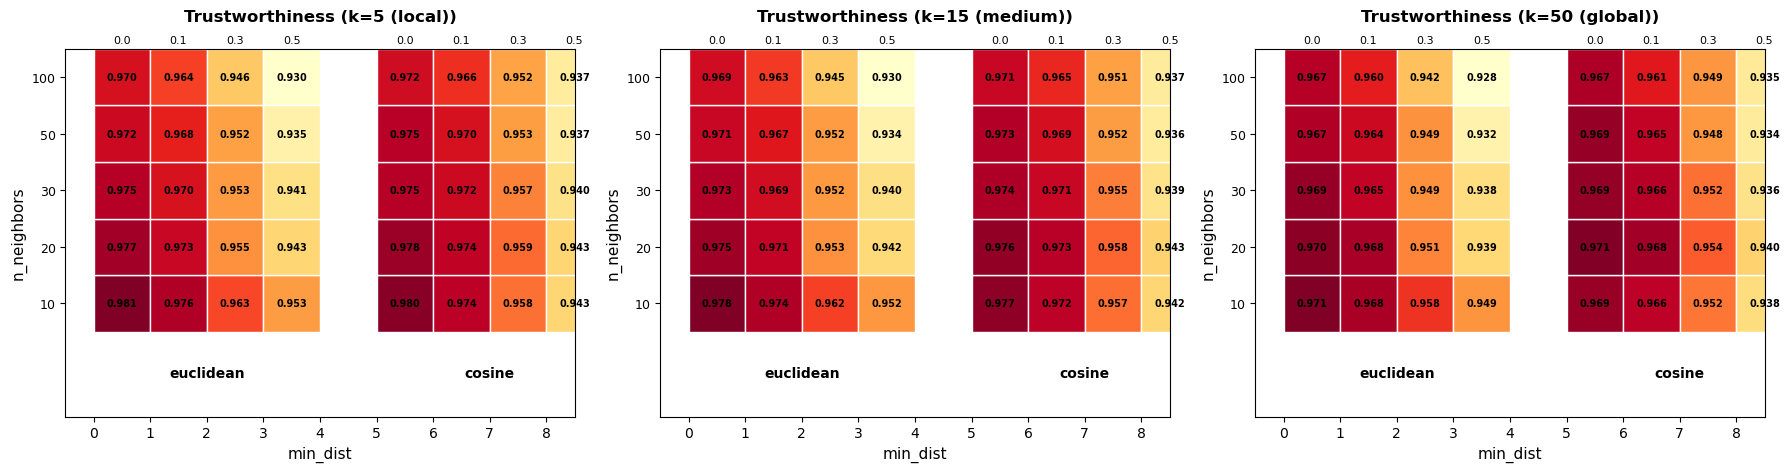

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (tw_col, k_label) in zip(axes, [
    ('trustworthiness_k5', 'k=5 (local)'),
    ('trustworthiness_k15', 'k=15 (medium)'),
    ('trustworthiness_k50', 'k=50 (global)'),
]):
    for i, metric in enumerate(metric_list):
        sub = results_df[results_df['metric'] == metric]
        pivot = sub.pivot(index='n_neighbors', columns='min_dist', values=tw_col)
        
        # Plot side by side within each subplot
        x_offset = i * (len(min_dist_list) + 1)
        for j, min_d in enumerate(min_dist_list):
            for k, n_neigh in enumerate(n_neighbors_list):
                val = pivot.loc[n_neigh, min_d]
                color = plt.cm.YlOrRd((val - results_df[tw_col].min()) / 
                                       (results_df[tw_col].max() - results_df[tw_col].min()))
                ax.add_patch(plt.Rectangle((x_offset + j, k), 1, 1, facecolor=color, edgecolor='white', linewidth=1))
                ax.text(x_offset + j + 0.5, k + 0.5, f'{val:.3f}',
                       ha='center', va='center', fontsize=7, fontweight='bold')
        
        # Metric label
        ax.text(x_offset + len(min_dist_list)/2, -0.8, metric,
               ha='center', fontsize=10, fontweight='bold')
    
    ax.set_xlim(-0.5, 2 * (len(min_dist_list) + 1) - 1.5)
    ax.set_ylim(-1.5, len(n_neighbors_list))
    ax.set_yticks([k + 0.5 for k in range(len(n_neighbors_list))])
    ax.set_yticklabels(n_neighbors_list, fontsize=9)
    ax.set_ylabel('n_neighbors', fontsize=11)
    
    # min_dist labels for each metric block
    for i_m in range(len(metric_list)):
        x_off = i_m * (len(min_dist_list) + 1)
        for j, md in enumerate(min_dist_list):
            ax.text(x_off + j + 0.5, len(n_neighbors_list) + 0.1, str(md),
                   ha='center', fontsize=8, rotation=0)
    
    ax.set_title(f'Trustworthiness ({k_label})', fontsize=12, fontweight='bold', pad=20)
    ax.set_xlabel('min_dist', fontsize=11)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('trustworthiness_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Summary Table — Sorted by Trustworthiness

In [5]:
# Composite score: average of the three trustworthiness measures
results_df['tw_avg'] = (results_df['trustworthiness_k5'] + 
                         results_df['trustworthiness_k15'] + 
                         results_df['trustworthiness_k50']) / 3

print('Top 10 configurations by average trustworthiness:\n')
top10 = results_df.sort_values('tw_avg', ascending=False).head(10)
print(top10[['metric', 'n_neighbors', 'min_dist', 
             'trustworthiness_k5', 'trustworthiness_k15', 'trustworthiness_k50',
             'tw_avg', 'fit_time']].to_string(index=False))

# Best overall
best = results_df.loc[results_df['tw_avg'].idxmax()]
print(f'\nBest: metric={best["metric"]}, n_neighbors={best["n_neighbors"]:.0f}, '
      f'min_dist={best["min_dist"]}, tw_avg={best["tw_avg"]:.4f}')

Top 10 configurations by average trustworthiness:

   metric  n_neighbors  min_dist  trustworthiness_k5  trustworthiness_k15  trustworthiness_k50   tw_avg  fit_time
euclidean           10       0.0            0.980998             0.978374             0.971481 0.976951 34.340644
   cosine           10       0.0            0.980201             0.976842             0.969231 0.975425 20.450729
   cosine           20       0.0            0.978166             0.976313             0.971309 0.975263 17.728073
euclidean           20       0.0            0.977250             0.975189             0.970203 0.974214 19.456021
   cosine           30       0.0            0.975381             0.973809             0.969452 0.972881 21.951198
euclidean           30       0.0            0.975206             0.973430             0.969408 0.972681 21.704549
   cosine           50       0.0            0.974914             0.973426             0.969415 0.972585 26.964529
euclidean           10       0.1     

## 4. Best Embedding Visualization

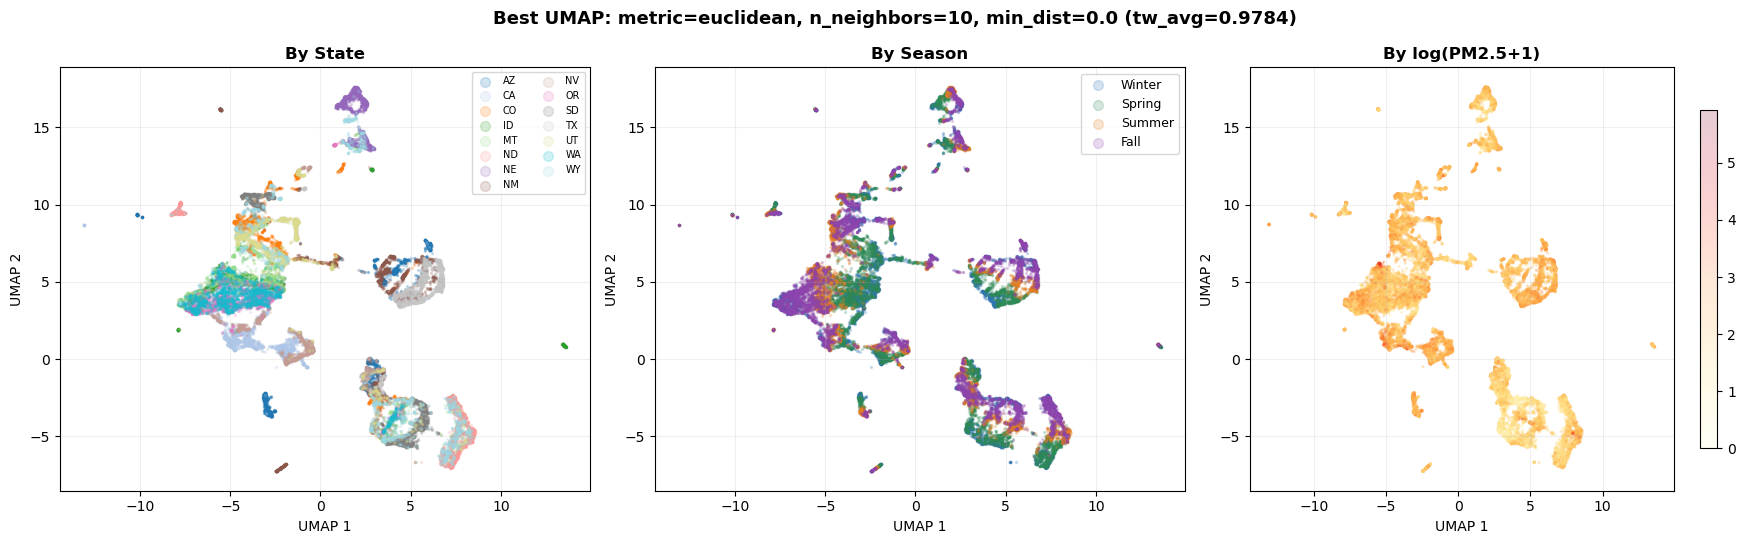

In [6]:
# Get best embedding
best_idx = results_df['tw_avg'].idxmax()
best_emb = results[best_idx]['embedding']
best_params = results[best_idx]

states = df_sample['state'].values
seasons = df_sample['season'].values
log_pm25 = np.log(df_sample['pm25'].values + 1)

unique_states = sorted(df_sample['state'].unique())
cmap_state = plt.cm.get_cmap('tab20', len(unique_states))
season_colors = {'Winter': '#2E75B6', 'Spring': '#2D8B57', 'Summer': '#E67E22', 'Fall': '#8E44AD'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(f'Best UMAP: metric={best_params["metric"]}, n_neighbors={best_params["n_neighbors"]}, '
             f'min_dist={best_params["min_dist"]} (tw_avg={best_params["trustworthiness_k15"]:.4f})',
             fontsize=13, fontweight='bold')

# By state
for i, st in enumerate(unique_states):
    mask = states == st
    axes[0].scatter(best_emb[mask, 0], best_emb[mask, 1],
                   s=2, alpha=0.2, color=cmap_state(i), label=st)
axes[0].set_title('By State', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=7, markerscale=5, ncol=2)
axes[0].grid(alpha=0.2)

# By season
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    mask = seasons == season
    axes[1].scatter(best_emb[mask, 0], best_emb[mask, 1],
                   s=2, alpha=0.2, color=season_colors[season], label=season)
axes[1].set_title('By Season', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, markerscale=5)
axes[1].grid(alpha=0.2)

# By PM2.5
sc = axes[2].scatter(best_emb[:, 0], best_emb[:, 1],
                    c=log_pm25, s=2, alpha=0.2, cmap='YlOrRd')
axes[2].set_title('By log(PM2.5+1)', fontsize=12, fontweight='bold')
plt.colorbar(sc, ax=axes[2], shrink=0.8)
axes[2].grid(alpha=0.2)

for ax in axes:
    ax.set_xlabel('UMAP 1', fontsize=10)
    ax.set_ylabel('UMAP 2', fontsize=10)

plt.tight_layout()
plt.savefig('best_umap_embedding.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Top 3 Embeddings Comparison

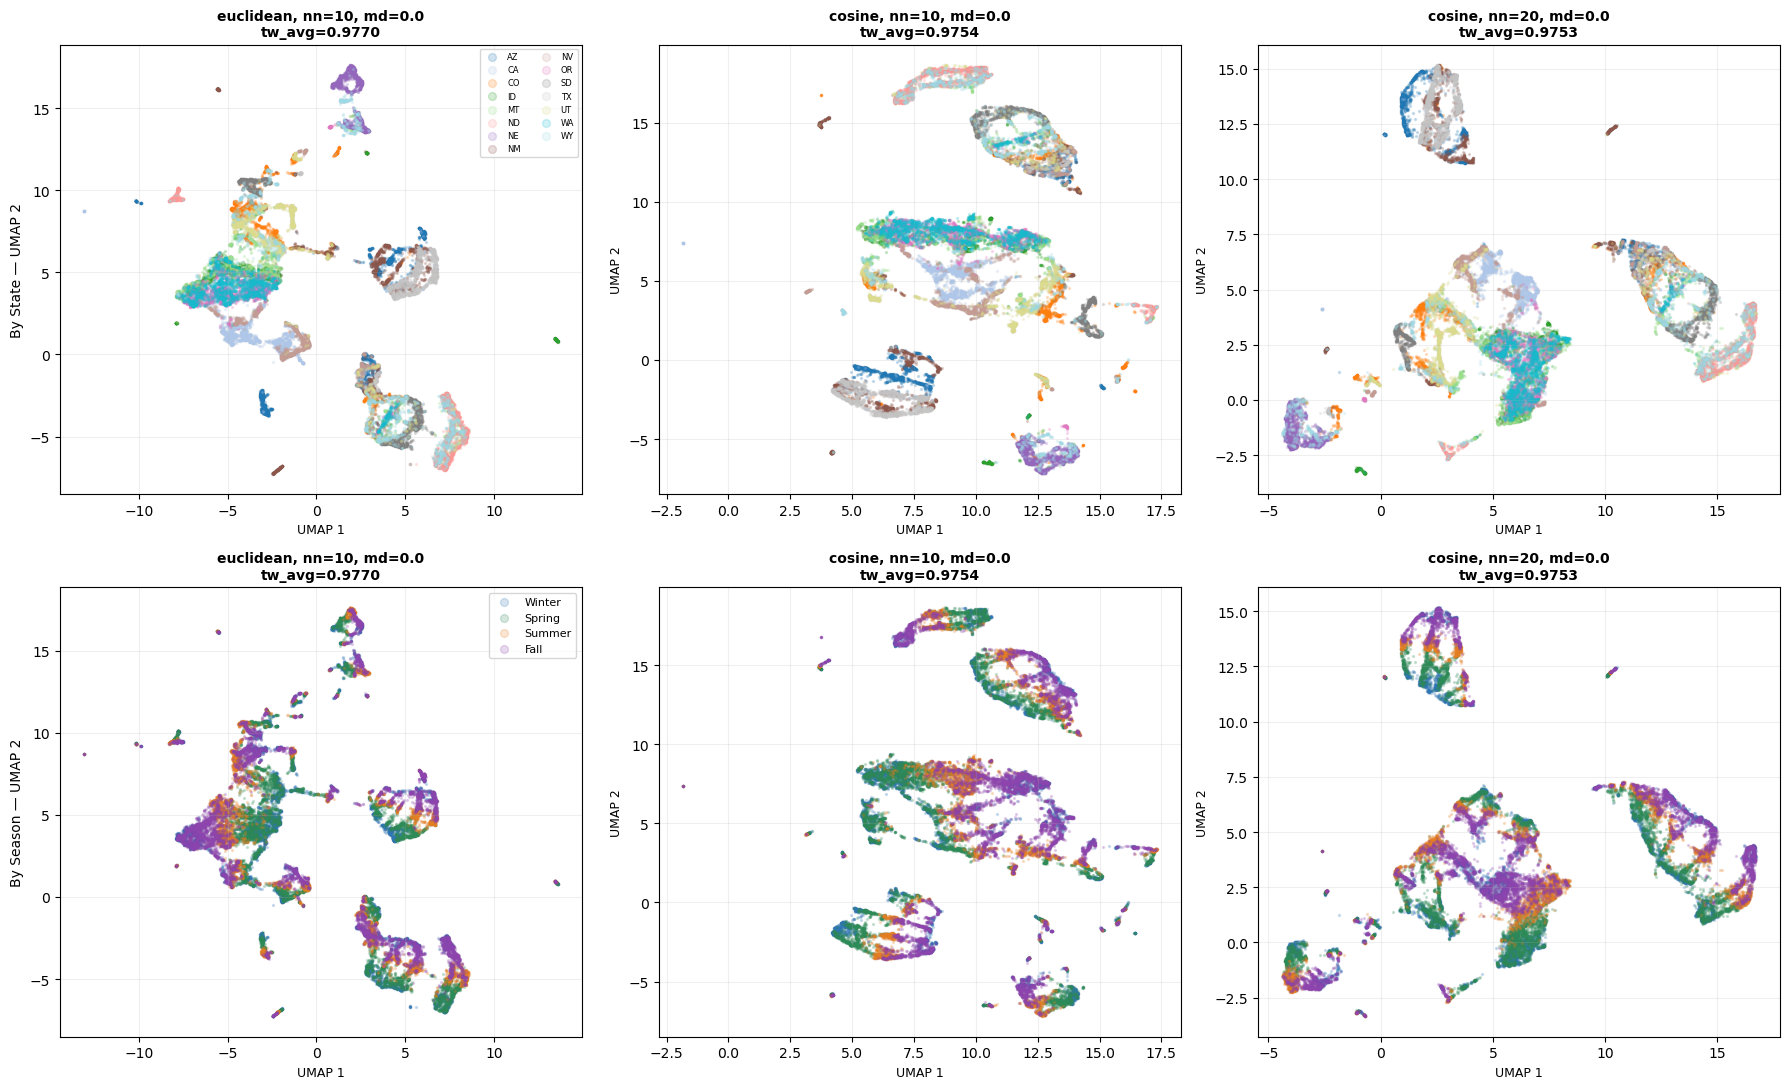

In [7]:
top3_idx = results_df.sort_values('tw_avg', ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for col, idx in enumerate(top3_idx):
    emb = results[idx]['embedding']
    r = results[idx]
    label = f"{r['metric']}, nn={r['n_neighbors']}, md={r['min_dist']}\ntw_avg={results_df.loc[idx, 'tw_avg']:.4f}"
    
    # Top row: by state
    for i, st in enumerate(unique_states):
        mask = states == st
        axes[0, col].scatter(emb[mask, 0], emb[mask, 1],
                            s=2, alpha=0.2, color=cmap_state(i), label=st)
    axes[0, col].set_title(label, fontsize=10, fontweight='bold')
    if col == 0:
        axes[0, col].legend(fontsize=6, markerscale=4, ncol=2)
    axes[0, col].grid(alpha=0.2)
    
    # Bottom row: by season
    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        mask = seasons == season
        axes[1, col].scatter(emb[mask, 0], emb[mask, 1],
                            s=2, alpha=0.2, color=season_colors[season], label=season)
    axes[1, col].set_title(label, fontsize=10, fontweight='bold')
    if col == 0:
        axes[1, col].legend(fontsize=8, markerscale=4)
    axes[1, col].grid(alpha=0.2)

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel('UMAP 1', fontsize=9)
        ax.set_ylabel('UMAP 2', fontsize=9)

axes[0, 0].set_ylabel('By State — UMAP 2', fontsize=10)
axes[1, 0].set_ylabel('By Season — UMAP 2', fontsize=10)

plt.tight_layout()
plt.savefig('top3_embeddings_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Trustworthiness vs n_neighbors Trade-off

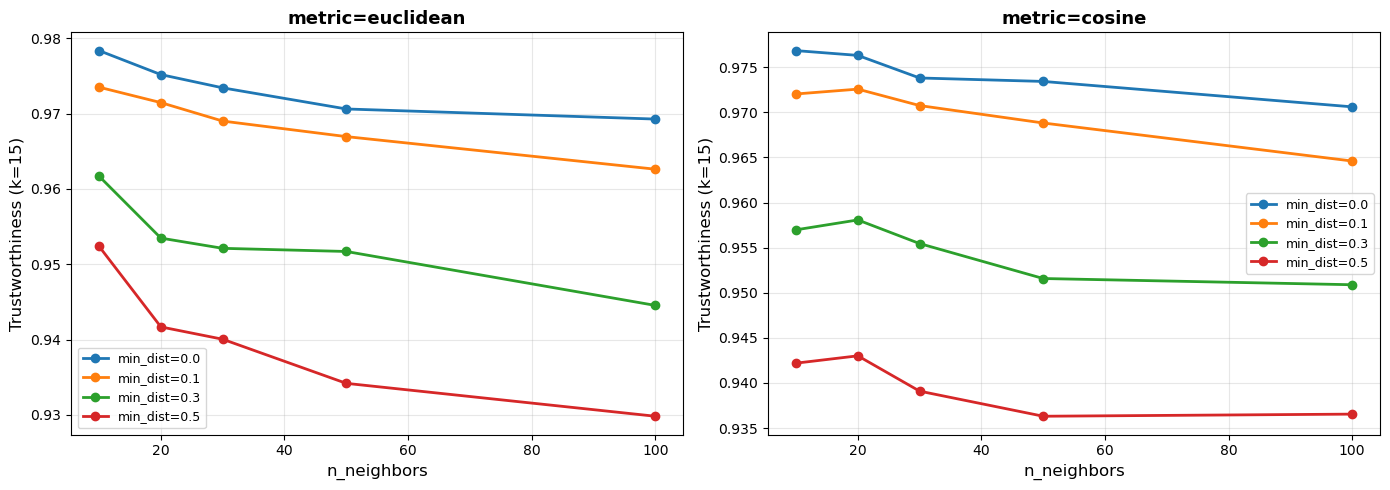

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, metric_list):
    sub = results_df[results_df['metric'] == metric]
    
    for min_d in min_dist_list:
        sub_md = sub[sub['min_dist'] == min_d]
        ax.plot(sub_md['n_neighbors'], sub_md['trustworthiness_k15'], 
               'o-', label=f'min_dist={min_d}', linewidth=2, markersize=6)
    
    ax.set_xlabel('n_neighbors', fontsize=12)
    ax.set_ylabel('Trustworthiness (k=15)', fontsize=12)
    ax.set_title(f'metric={metric}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trustworthiness_vs_neighbors.png', dpi=150, bbox_inches='tight')
plt.show()